## Building a Neural Network using Brian2 including FS and RS.

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

In this notebook we build a neural network using Brian2 and including FS and RS neurons.\
For details about the models, see the folder single_neuron_simulation).

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import h5py

In [2]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from utils.Brian_function_helper import *
from utils.Plots_helper import *
from utils.Sim_helper import *

INFO       Cache size for target "cython": 1007 MB.
You can call "clear_cache('cython')" to delete all files from the cache or manually delete files in the "/home/ilaria/.cython/brian_extensions" directory. [brian2]


In [4]:
saving_hdf5 = False

### Defining duration of the simulation

In [5]:
sim_duration = 10 * b2.second
dt = 0.1 * b2.ms  # time resolution
times = b2.arange(0, sim_duration, dt)

### Setting up the neuron models

In [6]:
data_folder = '../neuron_models/AdEx'
idx = 0 # in this case only one model per cell type is provided

#### Setting up holding current

In [7]:
# In case you don't want the current injected to be zero
# Comment the next three lines.
stim_t_start = 0
stim_t_end = int(sim_duration)
stim_amplitude = 0 * b2.nA

# Adding a "step of current" for testing
# Comment out next three lines if you like to inject a "step current".
#stim_t_start = 2   #seconds
#stim_t_end = 5     #seconds
#stim_amplitude = 0.35 * b2.nA

stim_unit = 1. * b2.ms
stim_time = sim_duration

# Setting up the step current injection protocol
tmp_size = 2 + stim_t_end  
tmp = np.zeros((tmp_size, 1)) * b2.amp
tmp[stim_t_start: stim_t_end + 1, 0] = stim_amplitude
curr_array = b2.TimedArray(tmp, dt=1. * stim_unit).values.flatten()  # to solve the issue with dimention of the current vector
current_timed_array = b2.TimedArray(curr_array * b2.amp, dt=stim_unit)

#### Reading in network configuration

In [8]:
network_config_folder = '../config/'
network_file_name = 'network_config_file_v1_no_adapt.json'

In [9]:
network_config = get_network_config(json_file_name =  os.path.join(network_config_folder, network_file_name))

In [10]:
network_config

{'metainfo': 'Network config file -- v1 no adaptation',
 'network_composition': {'tot_neurons': 10000,
  'FS_neuron': 2000,
  'RS_neuron': 8000,
  'conn_prob': 0.05},
 'external_input': {'N_external_exc': 8000,
  'N_external_inh': 2000,
  'conn_prob': 0.05},
 'rates': {'freq_exc_FS': 5,
  'freq_exc_RS': 3,
  'freq_inh_FS': 1,
  'freq_inh_RS': 10,
  'background_freq': 0.3},
 'units': {'freq_exc_FS': 'Hz',
  'freq_exc_RS': 'Hz',
  'freq_inh_FS': 'Hz',
  'freq_ing_RS': 'Hz',
  'background_freq': 'Hz'}}

#### Defining the neuron models and number of neurons per population

In [11]:
neuron_model = 'FS'
N_cell_FS = network_config['network_composition']['FS_neuron']
G_FS = setting_simulation_Brian(idx = idx,
                                 N_cell = N_cell_FS,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'),
                                 curr_inj = current_timed_array)

neuron_model = 'RS_no_adapt'
N_cell_RS = network_config['network_composition']['RS_neuron']
G_RS = setting_simulation_Brian(idx = idx,
                                 N_cell = N_cell_RS,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'),
                                 curr_inj = current_timed_array)


### Connecting the 2 populations

The neurons are connected through a random and sparse (Erdős-Rényi type) architecture.

In [12]:
conn_prob = network_config['network_composition']['conn_prob'] # connection probability

In [13]:
# Quantal increment in synaptic conductances
Qe_FS, Qi_FS = get_syn_info(json_file_name = os.path.join(data_folder, 'FS.json'))
Qe_RS, Qi_RS = get_syn_info(json_file_name = os.path.join(data_folder, 'RS.json'))


In [14]:
# Creating synapses -> connecting the populations
# We assume that:
# pop_1 is the inhibitory population, 
# pop_2 the excitatory population,
#'''

S_11, S_12, S_21, S_22 = network_creation(conn_prob = conn_prob,
                                         pop_1 = G_FS, 
                                         pop_2 = G_RS, 
                                         Qe_FS = Qe_FS, 
                                         Qi_FS = Qi_FS,
                                         Qe_RS = Qe_RS, 
                                         Qi_RS = Qi_RS,                                          
                                         seed = 12345)

# The function network_creation sets up all the connection.
# If you want to investigate the effect of a specific synapse,
# you can comment the previous interal synapse creation (i.e.you don't call the network_creation function)
# and use instead, for example:
'''
S_21 = b2.Synapses(G_RS, G_FS, on_pre='GsynE_post+=Qe_FS', name = 'S_21') 
S_21.connect(p=conn_prob)
S_12 = b2.Synapses(G_FS, G_RS, on_pre='GsynI_post+=Qi_RS', name = 'S_12')
S_12.connect(p=conn_prob)
'''

"\nS_21 = b2.Synapses(G_RS, G_FS, on_pre='GsynE_post+=Qe_FS', name = 'S_21') \nS_21.connect(p=conn_prob)\nS_12 = b2.Synapses(G_FS, G_RS, on_pre='GsynI_post+=Qi_RS', name = 'S_12')\nS_12.connect(p=conn_prob)\n"

In [15]:
int_syn = [S_11, S_12, S_21, S_22]
for syn in int_syn:
    print(syn.name, syn.source.name, '->', syn.target.name, f': {len(syn.i)} connections')

S_11 FS -> FS : 199660 connections
S_12 FS -> RS_no_adapt : 800265 connections
S_21 RS_no_adapt -> FS : 801507 connections
S_22 RS_no_adapt -> RS_no_adapt : 3201339 connections


### Defining the external drive/input

In [16]:
b2.seed(12345) # fixing seed for reproducibility 

# number of external neurons - number of incoming spikes
N_external_exc = network_config['external_input']['N_external_exc']
N_external_inh = network_config['external_input']['N_external_inh']
conn_prob =  network_config['external_input']['conn_prob']

rate_exc_background = network_config['rates']['background_freq'] * b2.Hz # firing rate of the external input
rate_exc_external_input_FS = network_config['rates']['freq_exc_FS'] * b2.Hz # firing rate of the external input
rate_exc_external_input_RS = network_config['rates']['freq_exc_RS'] * b2.Hz # firing rate of the external input

# Poissoninan background input activity
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 0 * b2.second
p_end = sim_duration
rate_array[(times >= p_start) & (times < p_end)] = rate_exc_background
# Create the TimedArray
rate_timed_array_all = b2.TimedArray(rate_array, dt=dt)


# Poissoninan input for FS neurons
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 1 * b2.second
p_end = 2 * b2.second
exc_interval_FS = (p_start/b2.second, p_end/b2.second, 'FS')
rate_array[(times >= p_start) & (times < p_end)] = rate_exc_external_input_FS
# Create the TimedArray
rate_timed_array_exc_FS = b2.TimedArray(rate_array, dt=dt)

# Poissoninan input for RS neurons
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 3 * b2.second
p_end = 4 * b2.second
exc_interval_RS = (p_start/b2.second, p_end/b2.second, 'RS')
rate_array[(times >= p_start) & (times < p_end)] = rate_exc_external_input_RS
rate_timed_array_exc_RS = b2.TimedArray(rate_array, dt=dt)

exc_intervals = [exc_interval_FS, exc_interval_RS] # used for plotting

P_ed_exc_all = b2.PoissonGroup(N_external_exc, rates='rate_timed_array_all(t)')
P_ed_exc_FS = b2.PoissonGroup(N_external_exc, rates='rate_timed_array_exc_FS(t)')
P_ed_exc_RS = b2.PoissonGroup(N_external_exc, rates='rate_timed_array_exc_RS(t)')


### Inhibitory external drive ###
rate_inh_external_input_FS = network_config['rates']['freq_inh_FS'] * b2.Hz # firing rate of the external input
rate_inh_external_input_RS = network_config['rates']['freq_inh_RS'] * b2.Hz # firing rate of the external input

# Poissoninan input for FS neurons
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 5 * b2.second
p_end = 6 * b2.second
inh_interval_FS = (p_start/b2.second, p_end/b2.second, 'FS')
rate_array[(times >= p_start) & (times < p_end)] = rate_inh_external_input_FS
# Create the TimedArray
rate_timed_array_inh_FS = b2.TimedArray(rate_array, dt=dt)

# Poissoninan input for RS neurons
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 7 * b2.second
p_end = 8 * b2.second
inh_interval_RS = (p_start/b2.second, p_end/b2.second, 'RS')
rate_array[(times >= p_start) & (times < p_end)] = rate_inh_external_input_RS
rate_timed_array_inh_RS = b2.TimedArray(rate_array, dt=dt)

inh_intervals = [inh_interval_FS, inh_interval_RS] # used for plotting


P_ed_inh_FS = b2.PoissonGroup(N_external_inh, rates='rate_timed_array_inh_FS(t)')
P_ed_inh_RS = b2.PoissonGroup(N_external_inh, rates='rate_timed_array_inh_RS(t)')

### Connecting the external input to the neuron models

In [17]:
# Background input (All the cell types receive the same and in our case Qe_FS=Qe_RS)
S_ed_background_FS = b2.Synapses(P_ed_exc_all, G_FS, on_pre='GsynE_post+=Qe_FS')
S_ed_background_FS.connect(p = conn_prob) # to have all-to-one connection remove the conn_prob
S_ed_background_RS = b2.Synapses(P_ed_exc_all, G_RS, on_pre='GsynE_post+=Qe_RS')
S_ed_background_RS.connect(p = conn_prob)

# Excitatory external input depending on the cell type
S_ed_exc_FS = b2.Synapses(P_ed_exc_FS, G_FS, on_pre='GsynE_post+=Qe_FS')
S_ed_exc_FS.connect(p = conn_prob)

S_ed_exc_RS = b2.Synapses(P_ed_exc_RS, G_RS, on_pre='GsynE_post+=Qe_RS')
S_ed_exc_RS.connect(p = conn_prob)

# Inhibitory external input depending on the cell type
S_ed_inh_FS = b2.Synapses(P_ed_inh_FS, G_FS, on_pre='GsynI_post+=Qi_FS')
S_ed_inh_FS.connect(p = conn_prob)

S_ed_inh_RS = b2.Synapses(P_ed_inh_RS, G_RS, on_pre='GsynI_post+=Qi_RS')
S_ed_inh_RS.connect(p = conn_prob)

### Defining the Monitors (variables to record)

In [18]:
mon_FS = b2.StateMonitor(G_FS, ['v', 'Is'], record=True)
mon_spike_FS = b2.SpikeMonitor(G_FS)

mon_RS = b2.StateMonitor(G_RS, ['v', 'Is'], record=True)
mon_spike_RS = b2.SpikeMonitor(G_RS)

mon_Poisson_input_exc_FS = b2.SpikeMonitor(P_ed_exc_FS)
mon_Poisson_input_exc_RS = b2.SpikeMonitor(P_ed_exc_RS)
mon_Poisson_input_all = b2.SpikeMonitor(P_ed_exc_all)

mon_Poisson_input_inh_FS = b2.SpikeMonitor(P_ed_inh_FS)
mon_Poisson_input_inh_RS = b2.SpikeMonitor(P_ed_inh_RS)

In [19]:
# to explore what's in the Monitor, use:
# print(dir(mon_FS))
# or for more details
# help(mon_FS)

### Running the simulation of the neural network containing the 2 populations

In [20]:
%%time
b2.run(sim_duration, namespace={'current': current_timed_array,
                                'rate_timed_array_all': rate_timed_array_all,
                                'rate_timed_array_exc_FS': rate_timed_array_exc_FS,
                                'rate_timed_array_exc_RS': rate_timed_array_exc_RS,
                                'rate_timed_array_inh_FS': rate_timed_array_inh_FS,
                                'rate_timed_array_inh_RS': rate_timed_array_inh_RS,
                                'Qe_FS': Qe_FS,
                                'Qi_FS': Qi_FS,
                                'Qe_RS': Qe_RS,
                                'Qi_RS': Qi_RS})

CPU times: user 35.5 s, sys: 8.27 s, total: 43.8 s
Wall time: 47.2 s


### Plotting the results

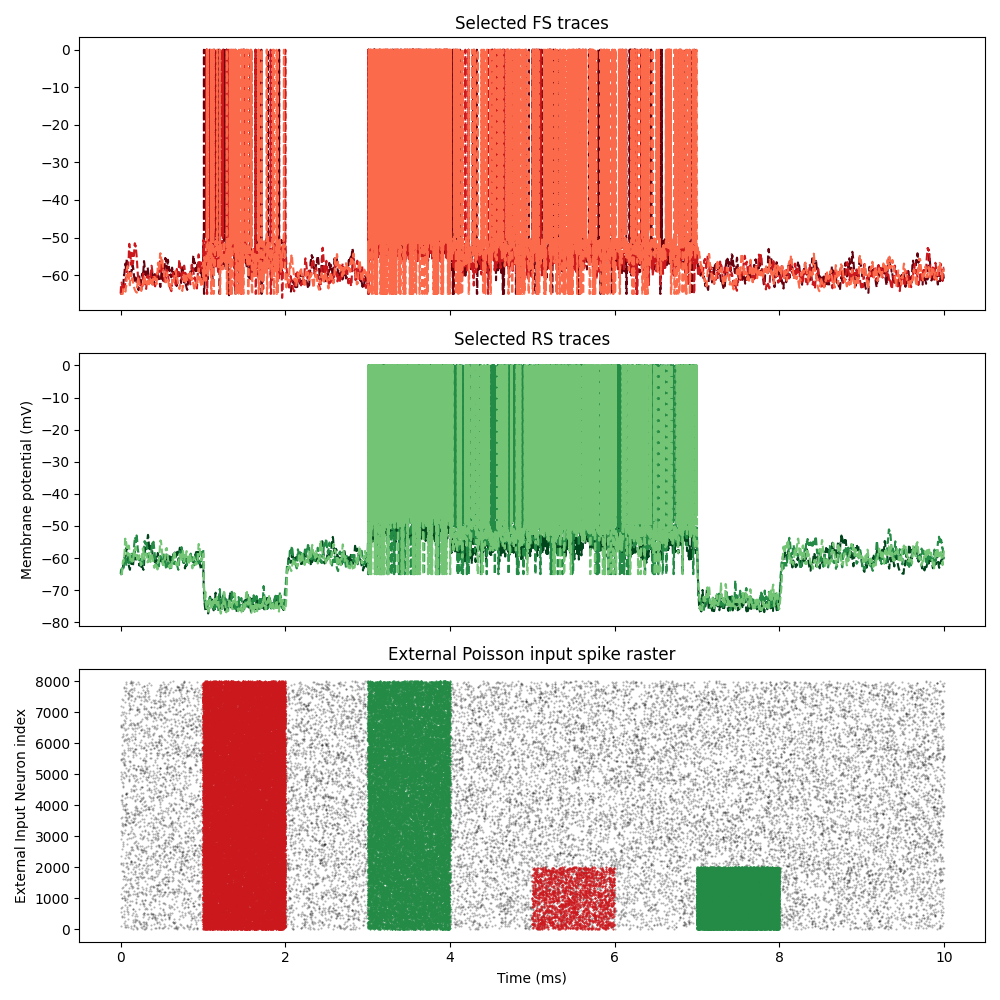

In [21]:
fig = plotting_3_traces_per_population(pop1 = mon_FS,
                                       pop2 = mon_RS,
                                       ext_input_0 = mon_Poisson_input_all,
                                       ext_input_1 = mon_Poisson_input_exc_FS,
                                       ext_input_2 = mon_Poisson_input_exc_RS,
                                       ext_input_3 = mon_Poisson_input_inh_FS,
                                       ext_input_4 = mon_Poisson_input_inh_RS,
                                       pretty_plot = True)


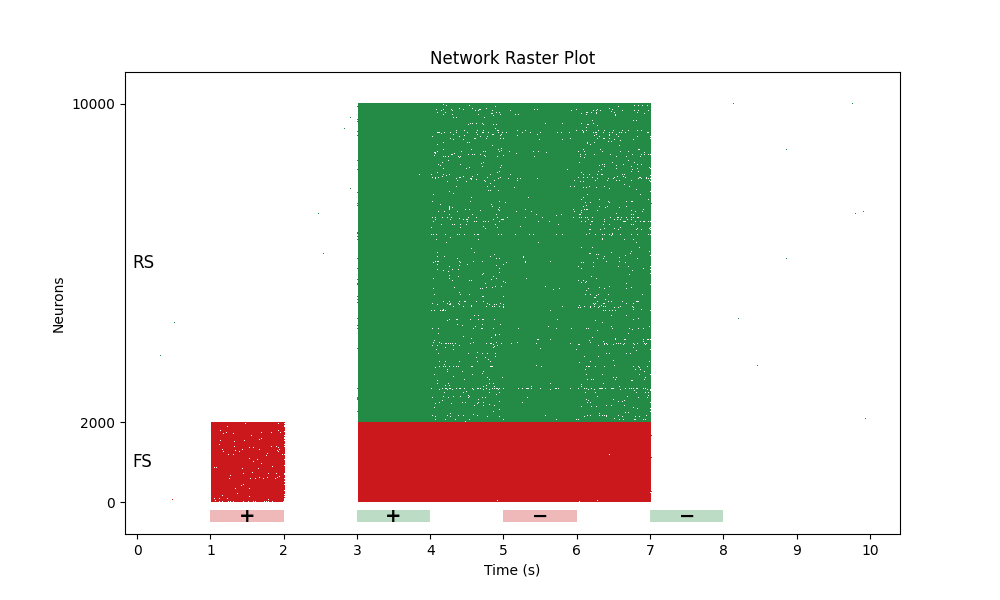

In [22]:
fig = network_raster_plot(pop1 = mon_spike_FS, 
                    pop2 = mon_spike_RS, 
                    N_pop1 = N_cell_FS,
                    N_pop2 = N_cell_RS,
                    exc_intervals=exc_intervals,
                    inh_intervals=inh_intervals)

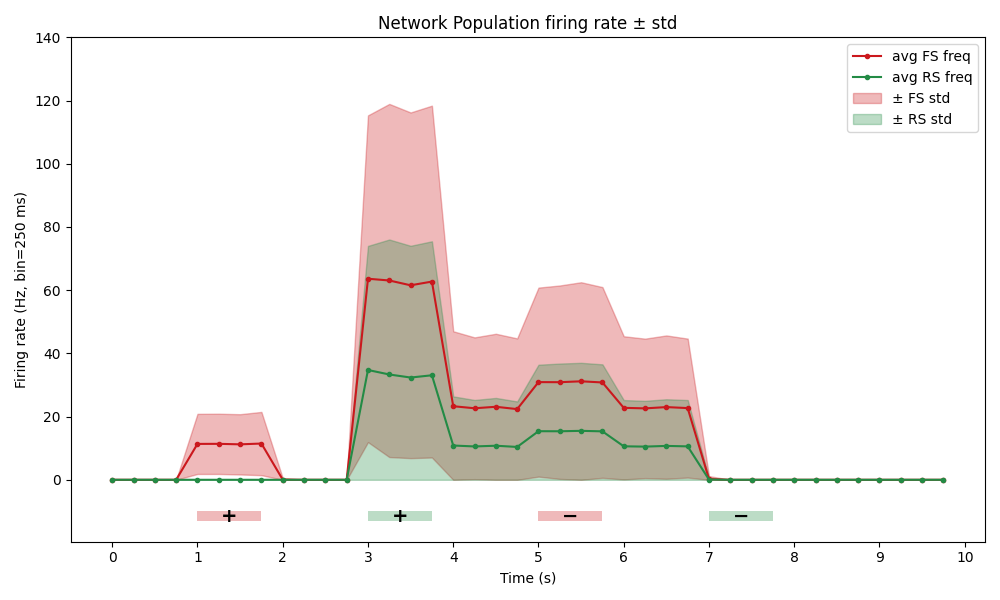

In [23]:
fig = plotting_pop_freq_and_std(sim_duration = sim_duration, 
                              pop1 = mon_spike_FS, 
                              pop2 = mon_spike_RS, 
                              N_pop1 = N_cell_FS,
                              N_pop2 = N_cell_RS,
                              bin_size = 250 * b2.ms,
                              exc_intervals=exc_intervals,
                              inh_intervals=inh_intervals)

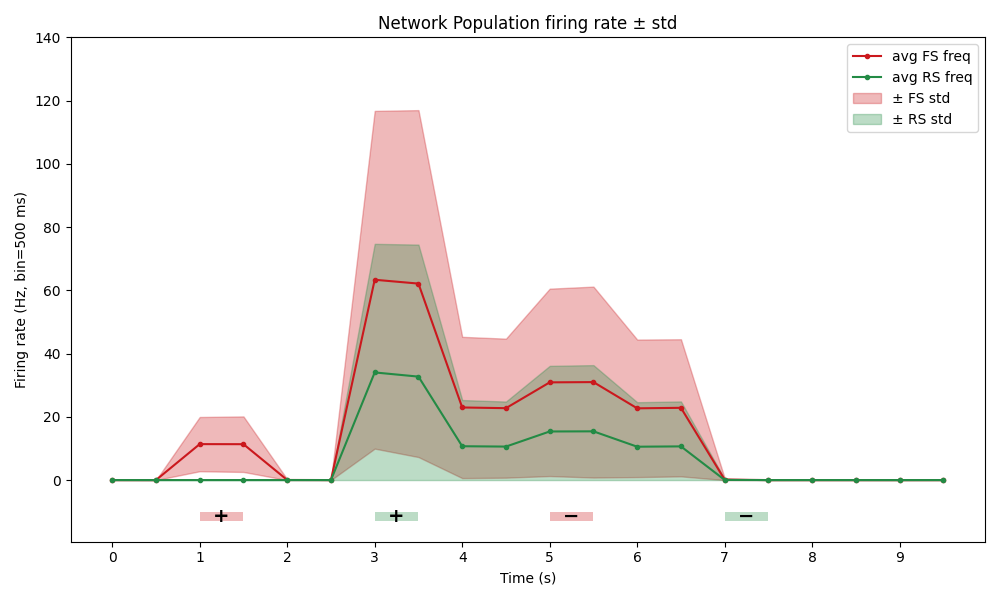

In [24]:
fig = plotting_pop_freq_and_std(sim_duration = sim_duration, 
                              pop1 = mon_spike_FS, 
                              pop2 = mon_spike_RS, 
                              N_pop1 = N_cell_FS,
                              N_pop2 = N_cell_RS,
                              bin_size = 500 * b2.ms,
                              exc_intervals=exc_intervals,
                              inh_intervals=inh_intervals)

It is interesting to notice that inhibition of the FS actually causes excitation of the RS and hence excitation of FS! So if the RS are spiking, and FS are inhibited, RS spike more (they are dishinibited) and as a consequence FS neurons get actually excitated by RS. So, the effect of the external inhibition on FS is very quickly "flipped". 

In [25]:
if saving_hdf5 == True:

    sim_path = os.path.join('simulations/test_0')
    isExist = os.path.exists(sim_path)
    if not isExist:
       os.makedirs(sim_path)
       print('The directory "simulations" is created.')
        
    with h5py.File(os.path.join(sim_path, "spikes_data.h5"), "w") as f:
        
        # --- network composition ---
        nc = f.create_group("network_composition")
        nc.create_dataset("num_FS_neurons", data = N_cell_FS)
        nc.create_dataset("num_RS_neurons", data = N_cell_RS)
        nc.create_dataset("conn_prob", data = network_config['network_composition']['conn_prob'])

        # --- external input ---   
        ei = f.create_group("external_input")
        ei.create_dataset("exc_input_FS_time_s", data = exc_interval_FS[0:2])       
        ei.create_dataset("exc_input_FS_freq_Hz", data = rate_exc_external_input_FS / b2.Hz)
        ei.create_dataset("exc_input_RS_time_s", data = exc_interval_RS[0:2])       
        ei.create_dataset("exc_input_RS_freq_Hz", data = rate_exc_external_input_RS / b2.Hz)
        ei.create_dataset("inh_input_FS_time_s", data = inh_interval_FS[0:2])       
        ei.create_dataset("inh_input_FS_freq_Hz", data = rate_inh_external_input_FS / b2.Hz)
        ei.create_dataset("inh_input_RS_time_s", data = inh_interval_RS[0:2])       
        ei.create_dataset("inh_input_RS_freq_Hz", data = rate_inh_external_input_RS / b2.Hz)
        
        # --- spikes ---
        spikes = f.create_group("spikes")
        spikes.create_dataset("sim_duration", data = sim_duration / b2.second)
        # FS population
        fs_group = spikes.create_group("FS")
        fs_group.create_dataset("i", data=mon_spike_FS.i, compression="gzip")
        fs_group.create_dataset("t", data=mon_spike_FS.t, compression="gzip")
        # RS population:
        rs_group = spikes.create_group("RS")
        rs_group.create_dataset("i", data=mon_spike_RS.i, compression="gzip")
        rs_group.create_dataset("t", data=mon_spike_RS.t, compression="gzip")
